In [ ]:
!pip -q install "transformers[torch]" datasets peft accelerate \
               scikit-learn sentencepiece emoji seaborn \
               huggingface_hub[hf_xet]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os, re, html, emoji, torch, pandas as pd, numpy as np, seaborn as sns
from datasets import Dataset, DatasetDict, disable_caching, ClassLabel
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from peft import LoraConfig, get_peft_model, TaskType

# TURNING OFF WandB auto‑init to prevent API‑key prompt
os.environ["WANDB_MODE"] = "disabled"
disable_caching()

In [ ]:
CSV_PATH = "/content/merged_tornado_tweets.csv"
ADAPTER_DIR_BIN = "/content/tweet_cls_lora_distilbert"
ADAPTER_DIR_MLT = "/content/tweet_cls_lora_multi"

In [ ]:
# 1 ▸  LOAD + CLEAN
# ----------------------------------------------------------------------
df = pd.read_csv(CSV_PATH)

def clean(txt):
    txt = html.unescape(str(txt))
    txt = emoji.replace_emoji(txt, replace='')
    txt = re.sub(r"http\S+|www\.\S+", " ", txt)
    txt = re.sub(r"@\w+", " ", txt)
    txt = re.sub(r"#", "", txt)
    txt = re.sub(r"\s{2,}", " ", txt)
    return txt.strip()

df["clean_text"] = df["text"].astype(str).map(clean)
df = df.dropna(subset=["clean_text","label"])
df = df[df["clean_text"].str.len() > 0]

# chronological split 70‑15‑15
df = df.sort_values("timestamp", na_position="last")
n = len(df)
train_df, val_df, test_df = (df.iloc[:int(.7*n)],
                             df.iloc[int(.7*n):int(.85*n)],
                             df.iloc[int(.85*n):])

tweet_ds = DatasetDict({
    "train"     : Dataset.from_pandas(train_df[["clean_text","label"]]),
    "validation": Dataset.from_pandas(val_df  [["clean_text","label"]]),
    "test"      : Dataset.from_pandas(test_df [["clean_text","label"]]),
}).cast_column("label", ClassLabel(num_classes=2))

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tok_fn(b): return tok(b["clean_text"], truncation=True,
                          padding="max_length", max_length=128)
tweet_ds = tweet_ds.map(tok_fn, batched=True, remove_columns=["clean_text"])\
                   .with_format("torch")

Casting the dataset:   0%|          | 0/14439 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3094 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3095 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/14439 [00:00<?, ? examples/s]

Map:   0%|          | 0/3094 [00:00<?, ? examples/s]

Map:   0%|          | 0/3095 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-8-c0cb7698fb1b>:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer_bin = WeightedTrainer(model_bin, args, tokenizer=tok,
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.287200,0.295102,0.922431,0.500000,0.461215,0.479825


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.287200,0.295102,0.922431,0.500000,0.461215,0.479825
2,0.218500,0.336810,0.915643,0.500000,0.457822,0.477982



Test (binary): {'eval_loss': 0.32245925068855286, 'eval_accuracy': 0.9066235864297254, 'eval_precision': 0.5, 'eval_recall': 0.4533117932148627, 'eval_f1': 0.47551262497881713, 'eval_runtime': 636.414, 'eval_samples_per_second': 4.863, 'eval_steps_per_second': 0.608, 'epoch': 2.9950138504155124}


[Text(0.5, 1.0, 'Binary\xa0CM')]

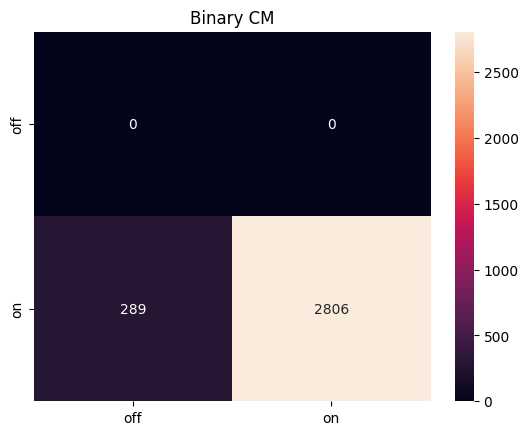

In [ ]:
# 2 ▸  2‑CLASS MODEL (LoRA + class‑weight loss)
# ----------------------------------------------------------------------
pos, neg = (train_df["label"]==1).sum(), (train_df["label"]==0).sum()
class_w  = torch.tensor([1.0, neg/(pos+1e-6)])

TARGETS = ["q_lin","k_lin","v_lin","out_lin","ffn.lin1","ffn.lin2"]
base_bin = AutoModelForSequenceClassification.from_pretrained(
              "distilbert-base-uncased", num_labels=2)
lora_cfg = LoraConfig(task_type=TaskType.SEQ_CLS, r=8,
                      lora_alpha=32, lora_dropout=0.05,
                      target_modules=TARGETS)
model_bin = get_peft_model(base_bin, lora_cfg)

from torch.nn import CrossEntropyLoss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        # weighted cross‑entropy
        loss_fn = CrossEntropyLoss(
    weight=class_w.to(logits.device).float())
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def metrics(ep):
    lg, y = ep
    p = torch.argmax(torch.tensor(lg), -1)
    acc = accuracy_score(y, p)
    pr,rc,f,_ = precision_recall_fscore_support(
                    y, p, average="macro", zero_division=0)
    return {"accuracy":acc,"precision":pr,"recall":rc,"f1":f}

args = TrainingArguments(output_dir=ADAPTER_DIR_BIN,
                         num_train_epochs=3,
                         per_device_train_batch_size=8,
                         per_device_eval_batch_size=8,
                         gradient_accumulation_steps=4,
                         learning_rate=2e-4, weight_decay=0.01,
                         eval_strategy="epoch", save_strategy="epoch",
                         load_best_model_at_end=True,
                         metric_for_best_model="f1",
                         greater_is_better=True,
                         fp16=torch.cuda.is_available(),
                         seed=42, logging_steps=100)

trainer_bin = WeightedTrainer(model_bin, args, tokenizer=tok,
                              train_dataset=tweet_ds["train"],
                              eval_dataset=tweet_ds["validation"],
                              compute_metrics=metrics)
trainer_bin.train()
print("\nTest (binary):", trainer_bin.evaluate(tweet_ds["test"]))
trainer_bin.model.save_pretrained(ADAPTER_DIR_BIN)

# quick confusion‑matrix
cm = confusion_matrix(tweet_ds["test"]["label"],
                      trainer_bin.predict(tweet_ds["test"]).predictions.argmax(-1))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["off","on"],
            yticklabels=["off","on"]).set(title="Binary CM")

In [ ]:
# 3 ▸  WEAK‑LABEL 4‑CLASS MODEL  (damage / request / warning / other)
# ----------------------------------------------------------------------
bucket = {
    "warning":  r"\bwarn(ing|ed)?\b|\btornado watch\b",
    "damage" :  r"\b(damage|debris|destroyed|injur(?:y|ies))\b",
    "request":  r"\b(help|need|shelter|donate)\b",
}
def weak(txt):
    txt = txt.lower()
    for k,p in bucket.items():
        if re.search(p, txt): return k
    return "other"
df["weak"] = df["clean_text"].map(weak)
lbl2id = {l:i for i,l in enumerate(sorted(df["weak"].unique()))}
df["mlabel"] = df["weak"].map(lbl2id)

ml_ds = DatasetDict({
    "train":      Dataset.from_pandas(df.iloc[:int(.7*n)][["clean_text","mlabel"]]),
    "validation": Dataset.from_pandas(df.iloc[int(.7*n):int(.85*n)][["clean_text","mlabel"]]),
    "test":       Dataset.from_pandas(df.iloc[int(.85*n):][["clean_text","mlabel"]]),
}).cast_column("mlabel", ClassLabel(num_classes=len(lbl2id)))\
  .map(tok_fn, batched=True, remove_columns=["clean_text"])\
  .with_format("torch")

base_multi = AutoModelForSequenceClassification.from_pretrained(
                 "distilbert-base-uncased", num_labels=len(lbl2id))
model_multi = get_peft_model(base_multi, lora_cfg)

args_multi = TrainingArguments(
    output_dir                = ADAPTER_DIR_MLT,
    num_train_epochs          = args.num_train_epochs,
    per_device_train_batch_size = args.per_device_train_batch_size,
    per_device_eval_batch_size  = args.per_device_eval_batch_size,
    gradient_accumulation_steps = args.gradient_accumulation_steps,
    learning_rate             = args.learning_rate,
    weight_decay              = args.weight_decay,
    eval_strategy             = args.eval_strategy,
    save_strategy             = args.save_strategy,
    load_best_model_at_end    = args.load_best_model_at_end,
    metric_for_best_model     = args.metric_for_best_model,
    greater_is_better         = args.greater_is_better,
    fp16                      = args.fp16,
    seed                      = args.seed,
    logging_steps             = args.logging_steps,
)
ml_ds = ml_ds.rename_column("mlabel", "labels")
trainer_multi = Trainer(
    model           = model_multi,
    args            = args_multi,
    train_dataset   = ml_ds["train"],
    eval_dataset    = ml_ds["validation"],
    tokenizer       = tok,
    compute_metrics = metrics
)
trainer_multi.train()
print("\nTest (weak‑multi):", trainer_multi.evaluate(ml_ds["test"]))
trainer_multi.model.save_pretrained(ADAPTER_DIR_MLT)

Casting the dataset:   0%|          | 0/14439 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3094 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3095 [00:00<?, ? examples/s]

Map:   0%|          | 0/14439 [00:00<?, ? examples/s]

Map:   0%|          | 0/3094 [00:00<?, ? examples/s]

Map:   0%|          | 0/3095 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-12-627ff1133089>:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_multi = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
A ConfigError was raised whilst setting the number of model parameters in Weights & Biases config.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.027800,0.025088,0.990627,0.968853,0.982696,0.975592


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.027800,0.025088,0.990627,0.968853,0.982696,0.975592
2,0.009000,0.005351,0.999030,0.996163,0.999022,0.997580


In [ ]:
# 4 ▸  LIGHTWEIGHT INFERENCE WRAPPER
# ----------------------------------------------------------------------
import torch.nn.functional as F
class TornadoTweetClassifier:
    def __init__(self, adapter_dir, labels):
        self.tok = tok
        self.id2lbl = labels
        base = AutoModelForSequenceClassification.from_pretrained(
                   "distilbert-base-uncased", num_labels=len(labels))
        self.model = get_peft_model(base, LoraConfig.from_pretrained(adapter_dir))
        self.model.eval()

    @torch.no_grad()
    def __call__(self, text):
        inp = self.tok(text, return_tensors="pt",
                       truncation=True, max_length=128)
        probs = F.softmax(self.model(**inp).logits, -1).squeeze().tolist()
        return {self.id2lbl[i]:p for i,p in enumerate(probs)}

bin_clf  = TornadoTweetClassifier(ADAPTER_DIR_BIN, {0:"off",1:"on"})
print("\nBinary demo:", bin_clf("tornado spotted near main street!"))

multi_clf = TornadoTweetClassifier(ADAPTER_DIR_MLT,
                                   {i:l for l,i in lbl2id.items()})
print("Multi‑class demo:", multi_clf("need water & blankets for tornado victims"))

NameError: name 'torch' is not defined